# Import Libraries

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# NeuralNetworkAdam class Implementation

In [2]:
class NeuralNetworkAdam:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.001, iterations=5000,
                 beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.iterations = iterations
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.cost_history = []

        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        # Adam first and second moment estimates
        self.m_W1 = np.zeros_like(self.W1)
        self.v_W1 = np.zeros_like(self.W1)
        self.m_b1 = np.zeros_like(self.b1)
        self.v_b1 = np.zeros_like(self.b1)
        self.m_W2 = np.zeros_like(self.W2)
        self.v_W2 = np.zeros_like(self.W2)
        self.m_b2 = np.zeros_like(self.b2)
        self.v_b2 = np.zeros_like(self.b2)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, z):
        s = self.sigmoid(z)
        return s * (1 - s)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        dz2 = self.a2 - y
        dW2 = (1 / m) * np.dot(self.a1.T, dz2)
        db2 = (1 / m) * np.sum(dz2, axis=0, keepdims=True)
        dz1 = np.dot(dz2, self.W2.T) * self.sigmoid_derivative(self.z1)
        dW1 = (1 / m) * np.dot(X.T, dz1)
        db1 = (1 / m) * np.sum(dz1, axis=0, keepdims=True)
        return dW1, db1, dW2, db2

    def adam_update(self, param, grad, m, v, t):
        # Update biased first moment estimate
        m = self.beta1 * m + (1 - self.beta1) * grad
        # Update biased second moment estimate
        v = self.beta2 * v + (1 - self.beta2) * (grad ** 2)
        # Bias correction
        m_hat = m / (1 - self.beta1 ** t)
        v_hat = v / (1 - self.beta2 ** t)
        # Update parameters
        param -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
        return param, m, v

    def cost(self, y_pred, y_true):
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y):
        y = y.reshape(-1, 1)

        for t in range(1, self.iterations + 1):
            y_pred = self.forward(X)
            dW1, db1, dW2, db2 = self.backward(X, y)

            # Adam updates for each parameter
            self.W1, self.m_W1, self.v_W1 = self.adam_update(self.W1, dW1, self.m_W1, self.v_W1, t)
            self.b1, self.m_b1, self.v_b1 = self.adam_update(self.b1, db1, self.m_b1, self.v_b1, t)
            self.W2, self.m_W2, self.v_W2 = self.adam_update(self.W2, dW2, self.m_W2, self.v_W2, t)
            self.b2, self.m_b2, self.v_b2 = self.adam_update(self.b2, db2, self.m_b2, self.v_b2, t)

            self.cost_history.append(self.cost(y_pred, y))

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

# NeuralNetworkSGD class Implementation (for comparison)

In [3]:
class NeuralNetworkSGD:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5, iterations=5000):
        self.lr = learning_rate
        self.iterations = iterations
        self.cost_history = []

        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, z):
        s = self.sigmoid(z)
        return s * (1 - s)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]
        dz2 = self.a2 - y
        dW2 = (1 / m) * np.dot(self.a1.T, dz2)
        db2 = (1 / m) * np.sum(dz2, axis=0, keepdims=True)
        dz1 = np.dot(dz2, self.W2.T) * self.sigmoid_derivative(self.z1)
        dW1 = (1 / m) * np.dot(X.T, dz1)
        db1 = (1 / m) * np.sum(dz1, axis=0, keepdims=True)
        return dW1, db1, dW2, db2

    def cost(self, y_pred, y_true):
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y):
        y = y.reshape(-1, 1)
        for i in range(self.iterations):
            y_pred = self.forward(X)
            dW1, db1, dW2, db2 = self.backward(X, y)
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.cost_history.append(self.cost(y_pred, y))

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

# Prepare Data

In [4]:
np.random.seed(42)
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Both Models

In [5]:
np.random.seed(42)
adam_model = NeuralNetworkAdam(input_size=2, hidden_size=8, output_size=1, learning_rate=0.01, iterations=3000)
adam_model.fit(X_train, y_train)

np.random.seed(42)
sgd_model = NeuralNetworkSGD(input_size=2, hidden_size=8, output_size=1, learning_rate=0.5, iterations=3000)
sgd_model.fit(X_train, y_train)

# Evaluate the Models

In [6]:
adam_pred = adam_model.predict(X_test)
sgd_pred = sgd_model.predict(X_test)

print(f"Adam Optimizer Accuracy: {np.mean(adam_pred.flatten() == y_test):.2f}")
print(f"SGD Optimizer Accuracy: {np.mean(sgd_pred.flatten() == y_test):.2f}")

Adam Optimizer Accuracy: 0.95
SGD Optimizer Accuracy: 0.85


# Visualize Cost Function Convergence

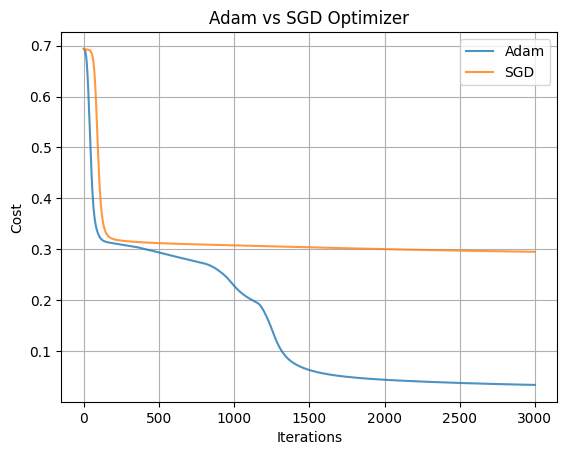

In [7]:
plt.plot(adam_model.cost_history, label='Adam', alpha=0.8)
plt.plot(sgd_model.cost_history, label='SGD', alpha=0.8)
plt.title('Adam vs SGD Optimizer')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()